# **04 - Gradient boosting (HistGradientBoostingRegressor)**

Histogram gradient boosting from scikit-learn on `y = log1p(target)` for the Jeonse (deposit) and Wolse (monthly rent) tracks. Predictions are back-transformed with `expm1` and evaluated in original wones on TEST (2025). LightGBM and SHAP are not installed in this environment, so scikit-learn is the only implementation and permutation importance plus partial dependence replace SHAP.

| model_id | Description |
|---|---|
| `hgb_static` | native categoricals (`district_name`, `building_type`, `contract_type`, `renewal_right_used`), `log_area`, `floor` (NaN kept), `floor_missing`, `building_age`; no time feature |
| `hgb_time` | `hgb_static` plus `t` (months since 2022-01) |
| `hgb_detrended` | log-linear month trend fit on TRAIN, boosting learns the residual, trend added back (extrapolated linearly) |
| `hgb_legal_dong` | `hgb_static` plus `legal_dong` (district + neighbourhood) as a categorical; levels with fewer than 30 TRAIN rows, and the levels beyond the 254 most frequent, are grouped into one "other" level |

**Early stopping.** `HistGradientBoostingRegressor` has no validation-tail option, so each fit is done in two steps on the rows it receives (TRAIN, or the training part of a CV fold): a first booster is fit on all rows except the last 6 months and its staged predictions on those 6 months select the number of iterations; the final booster is then refit on all rows with that number of iterations. `max_iter` is therefore an upper cap.

**Tuning.** `RandomizedSearchCV` (`n_iter=20`) over `learning_rate`, `max_iter`, `max_leaf_nodes`, `min_samples_leaf` and `l2_regularization`, with the 3-fold expanding-window folds and WAPE on the original scale as score. TEST is used only for the final evaluation.

**Prediction interval.** Quantile boosters (`loss='quantile'`, alpha 0.1 and 0.9) with the hyperparameters of the best variant give an 80% interval; its empirical coverage on TEST is reported below.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.inspection import permutation_importance

from rent_model import config
from rent_model.boosting import (VARIANTS as ALL_VARIANTS, feature_columns, fit_interval, fit_predict,
                                 interval_coverage, required_columns, to_original, tune, wape_scorer)
from rent_model.data import load_clean
from rent_model.features import build_features, build_target, select_track
from rent_model.io import save_run
from rent_model.metrics import all_metrics, wape
from rent_model.splits import expanding_window_folds, month_index, temporal_split

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 170)
plt.rcParams['figure.dpi'] = 100
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Data and splits

In [2]:
df = load_clean()
MODELS = {f'hgb_{v}': v for v in ALL_VARIANTS}
TUNING_ROWS = 60_000   # TRAIN subsample used for tuning only; final models are fit on the full TRAIN

data = {}
for track in config.TRACKS:
    train, test = temporal_split(select_track(df, track))
    sub = train.sample(TUNING_ROWS, random_state=config.RANDOM_SEED)
    build = lambda frame: build_features(frame, track, include_time=True, include_legal_dong=True)
    data[track] = dict(
        train=train, test=test, X_train=build(train), y_train=build_target(train, track),
        X_test=build(test), y_test=test[config.TRACKS[track]['target']],
        X_sub=build(sub), y_sub=build_target(sub, track), folds_sub=expanding_window_folds(sub))
    print(f"{track}: train {len(train):,} rows, test {len(test):,} rows; tuning subsample {len(sub):,} rows; "
          f"fold sizes (train, valid) {[(len(a), len(b)) for a, b in data[track]['folds_sub']]}")
    print('  legal_dong levels in TRAIN:', data[track]['X_train']['legal_dong'].nunique(),
          '| levels with >= 30 TRAIN rows:', int((data[track]['X_train']['legal_dong'].value_counts() >= 30).sum()))

jeonse: train 138,848 rows, test 37,935 rows; tuning subsample 60,000 rows; fold sizes (train, valid) [(21768, 13892), (35660, 12980), (48640, 11360)]
  legal_dong levels in TRAIN: 384 | levels with >= 30 TRAIN rows: 270
wolse: train 152,714 rows, test 57,829 rows; tuning subsample 60,000 rows; fold sizes (train, valid) [(19904, 13621), (33525, 12472), (45997, 14003)]
  legal_dong levels in TRAIN: 397 | levels with >= 30 TRAIN rows: 295


The tuning subsample is a seeded random sample of exactly 60,000 TRAIN rows per track; the 3 expanding-window folds are rebuilt on it, so each validation block lies after its training block. The final models are fit on the full TRAIN.

## Hyperparameter tuning (RandomizedSearchCV, n_iter=20)

In [3]:
tuning = {}
for track in config.TRACKS:
    d = data[track]
    for model_id, variant in MODELS.items():
        tuning[(track, model_id)] = tune(variant, d['X_sub'], d['y_sub'], d['folds_sub'], n_iter=20)

rows = []
for (track, model_id), (best, table) in tuning.items():
    top = table.iloc[0]
    rows.append({'track': track, 'model_id': model_id, **best, 'cv_wape_mean': top['cv_wape_mean'],
                 'cv_wape_std': top['cv_wape_std'], 'worst_candidate_cv_wape': table['cv_wape_mean'].max()})
display(pd.DataFrame(rows).set_index(['track', 'model_id']))

learning_rate  max_iter  max_leaf_nodes  min_samples_leaf  l2_regularization  cv_wape_mean  cv_wape_std  worst_candidate_cv_wape
track  model_id                                                                                                                                        
jeonse hgb_static             0.0500      1000             127                10             1.0000       18.2933       0.7671                  18.9700
       hgb_time               0.0300       600             127                20             0.0000       17.6560       0.3552                  18.2869
       hgb_detrended          0.0300       600             127                20             0.0000       18.0605       1.5864                  18.7085
       hgb_legal_dong         0.0300       600             127                20             0.0000       16.4473       0.9566                  16.9438
wolse  hgb_static             0.0300       300             127               100            10.0000       42.8616       2.2689                  43.0223
       hgb_time               0.0500       600              15                50            10.0000       43.0728       2.6081                  43.3245
       hgb_detrended          0.0300       300             127               100            10.0000       42.1521       2.2542                  42.3302
       hgb_legal_dong         0.0300      1000              31                50            10.0000       42.2466       1.8410                  42.5097

**Interpretation.** In every search the best and the worst of the 20 candidates are close (for example Jeonse `hgb_static` 18.2933% against 18.9700%, Wolse `hgb_static` 42.8616% against 43.0223%); boosting is therefore not very sensitive to these five hyperparameters on this data. `max_leaf_nodes=127`, the upper edge of the grid, is selected in six of the eight searches, and `learning_rate=0.03`, the lower edge, in six, so larger trees and a smaller learning rate might still gain a little. The CV score already shows the value of neighbourhood detail: `hgb_legal_dong` has the lowest CV WAPE in Jeonse (16.4473%, against 18.2933% for `hgb_static`) and in Wolse it is within 0.1 points of `hgb_detrended` (42.2466% against 42.1521%). Fold-to-fold standard deviations are between 0.3552 and 2.6081 points.

## Fit on the full TRAIN and evaluate on TEST (2025)

In [4]:
fitted, preds, rows = {}, {}, []
for track in config.TRACKS:
    d = data[track]
    for model_id, variant in MODELS.items():
        best, table = tuning[(track, model_id)]
        model, pred = fit_predict(variant, best, d['X_train'], d['y_train'], d['X_test'])
        fitted[(track, model_id)], preds[(track, model_id)] = model, pred
        rows.append({'track': track, 'model_id': model_id, 'iterations_after_early_stopping': model.n_iter_,
                     **all_metrics(d['y_test'].to_numpy(), pred)})
metrics = pd.DataFrame(rows)

def last_run(track, model_id):
    return json.loads((config.METRICS_DIR / f'{track}__{model_id}.json').read_text(encoding='utf-8'))[-1]

cols = ['n', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']
for track in config.TRACKS:
    table = metrics[metrics['track'] == track].set_index('model_id')[['iterations_after_early_stopping'] + cols]
    for ref_id in ['baseline_district_type_area', 'ridge_time_rich', 'rf_time', 'rf_detrended']:
        run = last_run(track, ref_id)
        table.loc[f'(ref) {ref_id}'] = [np.nan] + [run[c] for c in cols]
    print(f'TEST metrics - {track}')
    display(table)
for track in config.TRACKS:
    m = fitted[(track, 'hgb_detrended')]
    print(f"{track}: detrended trend slope {m.slope_:.5f} log points per month, intercept {m.intercept_:.4f}")

TEST metrics - jeonse


,iterations_after_early_stopping,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,,
hgb_static,964.0000,"37,935.0000",18.5858,"8,376.7595",14.2813,-7.7759,-9.3616,0.2852,0.8575
hgb_time,566.0000,"37,935.0000",17.3111,"7,802.2305",13.0657,-3.9480,-4.0113,0.2817,0.8609
hgb_detrended,600.0000,"37,935.0000",17.6481,"7,954.1463",13.3657,5.2326,3.3864,0.2925,0.8501
hgb_legal_dong,600.0000,"37,935.0000",15.8354,"7,137.1232",12.6760,-7.3684,-8.5658,0.2556,0.8855
(ref) baseline_district_type_area,NaN,"37,935.0000",27.2510,"12,282.2552",20.3822,-4.7619,-10.2899,0.3909,0.7322
(ref) ridge_time_rich,NaN,"37,935.0000",23.0944,"10,408.8488",17.9308,-8.2595,-10.6128,0.3428,0.7941
(ref) rf_time,NaN,"37,935.0000",17.9051,"8,069.9658",13.6291,-5.1635,-6.4563,0.2912,0.8514
(ref) rf_detrended,NaN,"37,935.0000",17.9091,"8,071.7713",13.5941,5.2498,2.7507,0.3003,0.8419


TEST metrics - wolse


,iterations_after_early_stopping,n,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,rmse_log,r2_log
model_id,,,,,,,,,
hgb_static,299.0000,"57,829.0000",45.5432,34.1412,36.0367,-17.6542,-23.2012,0.6944,0.3454
hgb_time,600.0000,"57,829.0000",45.7417,34.2900,37.3742,-18.2042,-22.4644,0.6973,0.3400
hgb_detrended,298.0000,"57,829.0000",45.3293,33.9808,35.7666,-16.9244,-22.4758,0.6942,0.3459
hgb_legal_dong,"1,000.0000","57,829.0000",44.3335,33.2343,35.3340,-16.9086,-21.6673,0.6837,0.3655
(ref) baseline_district_type_area,NaN,"57,829.0000",46.9591,35.2026,32.5301,-7.4074,-14.5804,0.7641,0.2075
(ref) ridge_time_rich,NaN,"57,829.0000",49.0983,36.8062,39.1765,-20.2776,-28.9682,0.7336,0.2695
(ref) rf_time,NaN,"57,829.0000",46.3507,34.7465,37.1325,-17.2760,-24.0149,0.7053,0.3248
(ref) rf_detrended,NaN,"57,829.0000",45.7560,34.3007,35.7110,-16.1919,-23.1224,0.6997,0.3355


jeonse: detrended trend slope 0.00583 log points per month, intercept 10.1794
wolse: detrended trend slope 0.00039 log points per month, intercept 3.9268


**Interpretation (Jeonse).** `hgb_legal_dong` is the best model so far: TEST WAPE 15.84% and `r2_log` 0.8855, against 17.31% for `hgb_time`, 18.59% for `hgb_static`, 17.91% for `rf_time` and 23.09% for `ridge_time_rich`. Adding `t` helps (18.59% to 17.31%, median bias -7.78% to -3.95%), the detrended variant overshoots again (median bias +5.23%, aggregate +3.39%) and `hgb_legal_dong` keeps the negative bias of the static model (median -7.37%, aggregate -8.57%). The number of iterations after early stopping equals the grid cap in four models (600 for Jeonse `hgb_detrended` and `hgb_legal_dong`, 600 for Wolse `hgb_time` and 1,000 for Wolse `hgb_legal_dong`) and is close to it in Jeonse `hgb_static` (964 of 1,000), so the cap, and not the validation tail, limited those fits.

**Interpretation (Wolse).** The four variants have a TEST WAPE between 44.33% and 45.74%. `hgb_legal_dong` is again the best (44.33%, `r2_log` 0.3655) and improves on the naive baseline (46.96%) by WAPE, but the bias remains much larger than the baseline's (median bias -16.91% against -7.41%, aggregate -21.67% against -14.58%). The time variant does not help in Wolse (45.74% against 45.54% for `hgb_static`), and the fitted Wolse trend is only 0.00039 log points per month.

## Prediction interval (quantile boosters, 10% and 90%)

In [5]:
best_id, intervals, interval_rows = {}, {}, []
for track in config.TRACKS:
    d = data[track]
    m = metrics[metrics['track'] == track].set_index('model_id')
    best_id[track] = m['wape_pct'].idxmin()
    variant = MODELS[best_id[track]]
    lower, upper = fit_interval(variant, tuning[(track, best_id[track])][0], d['X_train'], d['y_train'], d['X_test'])
    intervals[track] = (lower, upper)
    y = d['y_test'].to_numpy()
    coverage, width = interval_coverage(y, lower, upper)
    interval_rows.append({'track': track, 'model': best_id[track], 'nominal': 0.80, 'coverage': coverage,
                          'below_lower': float(np.mean(y < lower)), 'above_upper': float(np.mean(y > upper)),
                          'mean_width': width, 'median_width_over_median_pred': float(np.median((upper - lower) / preds[(track, best_id[track])]))})
display(pd.DataFrame(interval_rows).set_index('track'))

for track in config.TRACKS:
    d = data[track]; lower, upper = intervals[track]
    frame = pd.DataFrame({'y': d['y_test'].to_numpy(), 'lo': lower, 'hi': upper,
                          'quarter': d['test']['contract_date'].dt.quarter.to_numpy(),
                          'building_type': d['test']['building_type'].to_numpy()})
    frame['inside'] = (frame['y'] >= frame['lo']) & (frame['y'] <= frame['hi'])
    print(f'{track}: coverage by quarter');  display(frame.groupby('quarter')['inside'].mean().to_frame('coverage'))
    print(f'{track}: coverage by building_type'); display(frame.groupby('building_type')['inside'].mean().to_frame('coverage'))

,model,nominal,coverage,below_lower,above_upper,mean_width,median_width_over_median_pred
track,,,,,,,
jeonse,hgb_legal_dong,0.8000,0.6889,0.0802,0.2309,"17,861.9131",0.4025
wolse,hgb_legal_dong,0.8000,0.6493,0.1210,0.2296,78.4963,1.2649


jeonse: coverage by quarter


,coverage
quarter,
1,0.7258
2,0.7051
3,0.6849
4,0.6246


jeonse: coverage by building_type


,coverage
building_type,
Apartment,0.6792
Detached / Multi-household house,0.6900
Officetel,0.6302
Row house / Villa (multi-unit),0.7407


wolse: coverage by quarter


,coverage
quarter,
1,0.6658
2,0.6599
3,0.6301
4,0.6382


wolse: coverage by building_type


,coverage
building_type,
Apartment,0.6621
Detached / Multi-household house,0.6759
Officetel,0.5466
Row house / Villa (multi-unit),0.6795


**Interpretation.** The 80% intervals of the best model undercover on TEST: the empirical coverage is 0.6889 in Jeonse and 0.6493 in Wolse. The misses are asymmetric: the actual value is above the upper bound in 0.2309 (Jeonse) and 0.2296 (Wolse) of the rows and below the lower bound in 0.0802 and 0.1210, which is consistent with the negative bias of the squared-loss models; notebook 10 shows that this bias is also present in the 2023 and 2024 pseudo-tests in Wolse, so it is not specific to 2025. In Jeonse coverage falls during the year, from 0.7258 in Q1 to 0.6246 in Q4, and by building type it ranges from 0.6302 (Officetel) to 0.7407 (Row house / Villa). In Wolse coverage ranges from 0.5466 (Officetel) to 0.6795 (Row house / Villa), and the intervals are wide (the median width is 1.2649 times the point prediction) while still undercovering. The quantile models were trained on 2022-2024 and carry the level bias of the point models, so the intervals should not be read as calibrated for 2025.

## Save runs

In [6]:
for track in config.TRACKS:
    d = data[track]
    for model_id, variant in MODELS.items():
        best, table = tuning[(track, model_id)]
        model = fitted[(track, model_id)]
        meta = {'variant': variant, 'params': best, 'iterations_after_early_stopping': int(model.n_iter_),
                'cv_wape_mean': float(table.loc[0, 'cv_wape_mean']), 'tuning_rows': TUNING_ROWS,
                'features': feature_columns(variant), 'early_stopping_tail_months': 6,
                'fit_period': '2022-01-01..2024-12-31', 'eval_period': '2025'}
        if variant == 'detrended':
            meta.update(trend_slope_log_per_month=float(model.slope_), trend_intercept_log=float(model.intercept_))
        has_interval = model_id == best_id[track]
        if has_interval:
            lower, upper = intervals[track]
            meta['interval'] = {'method': 'HistGradientBoosting quantile loss, same hyperparameters',
                                'quantiles': [0.1, 0.9], 'nominal_coverage': 0.8,
                                'coverage_test': float(np.mean((d['y_test'].to_numpy() >= lower) & (d['y_test'].to_numpy() <= upper))),
                                'mean_lower': float(lower.mean()), 'mean_upper': float(upper.mean()),
                                'median_lower': float(np.median(lower)), 'median_upper': float(np.median(upper)),
                                'row_level_bounds_columns': ['lower_p10', 'upper_p90']}
        pred_path, _ = save_run(track, model_id, d['y_test'], preds[(track, model_id)], meta=meta,
                                context=d['test'][['district_name', 'contract_date']])
        if has_interval:   # row-level bounds go into this model's own predictions file
            saved = pd.read_parquet(pred_path)
            saved['lower_p10'], saved['upper_p90'] = lower, upper
            saved.to_parquet(pred_path, index=False)
print('Best model per track (lowest TEST WAPE), with interval saved:', best_id)

Best model per track (lowest TEST WAPE), with interval saved: {'jeonse': 'hgb_legal_dong', 'wolse': 'hgb_legal_dong'}


## Bias by quarter (TEST 2025)

In [7]:
def bias_table(track, kind):
    d = data[track]; q = d['test']['contract_date'].dt.quarter
    out = {}
    for model_id in MODELS:
        frame = pd.DataFrame({'y': d['y_test'].to_numpy(), 'p': preds[(track, model_id)], 'q': q.to_numpy()})
        if kind == 'median':
            out[model_id] = frame.groupby('q').apply(lambda g: np.median((g['p'] - g['y']) / g['y']) * 100, include_groups=False)
        else:
            out[model_id] = frame.groupby('q').apply(lambda g: (g['p'].sum() - g['y'].sum()) / g['y'].sum() * 100, include_groups=False)
    return pd.DataFrame(out)

for track in config.TRACKS:
    print(f'{track}: median bias % by quarter'); display(bias_table(track, 'median'))
    print(f'{track}: aggregate bias % by quarter'); display(bias_table(track, 'aggregate'))

jeonse: median bias % by quarter


,hgb_static,hgb_time,hgb_detrended,hgb_legal_dong
q,,,,
1,-6.1271,-2.1899,4.5404,-5.8526
2,-6.7014,-2.6684,5.7106,-6.4778
3,-8.0948,-4.4908,5.8174,-7.8875
4,-10.7661,-6.8928,4.5620,-10.1812


jeonse: aggregate bias % by quarter


,hgb_static,hgb_time,hgb_detrended,hgb_legal_dong
q,,,,
1,-6.8294,-1.3390,3.5847,-6.5881
2,-8.4179,-2.8731,3.8652,-7.5046
3,-9.9655,-4.6600,3.8765,-9.0571
4,-12.7733,-7.7599,2.0896,-11.5748


wolse: median bias % by quarter


,hgb_static,hgb_time,hgb_detrended,hgb_legal_dong
q,,,,
1,-16.1005,-16.6934,-15.5569,-15.2465
2,-17.0888,-17.3754,-16.3191,-16.6846
3,-19.5333,-20.4067,-18.7769,-18.5356
4,-18.3676,-19.0530,-17.4805,-17.3075


wolse: aggregate bias % by quarter


,hgb_static,hgb_time,hgb_detrended,hgb_legal_dong
q,,,,
1,-20.6206,-20.0219,-20.0447,-19.2042
2,-23.3094,-22.5286,-22.5927,-21.8233
3,-25.4731,-24.6740,-24.6930,-23.5885
4,-23.4772,-22.7011,-22.6313,-22.1532


**Interpretation.** In Jeonse the median bias of `hgb_static` worsens through 2025, from -6.13% in Q1 to -10.77% in Q4 (aggregate from -6.83% to -12.77%), and `hgb_legal_dong` follows the same path (-5.85% to -10.18%). `hgb_time` starts closer (-2.19% in Q1) and also drifts (-6.89% in Q4). `hgb_detrended` keeps a roughly constant positive bias (between +4.54% and +5.82% for the median), i.e. it follows the rise but over-corrects. In Wolse all four variants underpredict in every quarter (median bias between -15.25% and -20.41%, aggregate between -19.20% and -25.47%), with the largest gap in Q3.

## Permutation importance (TEST subsample, best model per track)

In [8]:
PERM_ROWS = 5_000
for track in config.TRACKS:
    d = data[track]; variant = MODELS[best_id[track]]
    cols_ = feature_columns(variant) + ([config.TIME_FEATURE] if variant == 'detrended' else [])   # the model's own features (the trend of 'detrended' uses t)
    idx = d['X_test'].sample(PERM_ROWS, random_state=config.RANDOM_SEED).index
    result = permutation_importance(fitted[(track, best_id[track])], d['X_test'].loc[idx, cols_],
                                    np.log1p(d['y_test'].loc[idx]), scoring=wape_scorer, n_repeats=5,
                                    random_state=config.RANDOM_SEED, n_jobs=1)
    table = pd.DataFrame({'wape_increase_pts': result.importances_mean, 'std': result.importances_std},
                         index=cols_).sort_values('wape_increase_pts', ascending=False)
    print(f"{track}: {best_id[track]} - increase in TEST WAPE (percentage points) when one of the model's own features is permuted; "
          f"{PERM_ROWS:,} TEST rows, 5 repeats")
    display(table)

jeonse: hgb_legal_dong - increase in TEST WAPE (percentage points) when one of the model's own features is permuted; 5,000 TEST rows, 5 repeats


,wape_increase_pts,std
log_area,32.1585,0.4446
legal_dong,19.7943,0.2959
building_age,13.0109,0.2500
building_type,10.9252,0.1973
floor,1.9433,0.0994
district_name,0.3933,0.0230
contract_type,0.1923,0.0229
renewal_right_used,0.0485,0.0147
floor_missing,0.0000,0.0000


wolse: hgb_legal_dong - increase in TEST WAPE (percentage points) when one of the model's own features is permuted; 5,000 TEST rows, 5 repeats


,wape_increase_pts,std
log_area,13.4381,0.2529
legal_dong,7.4198,0.1705
building_type,3.8166,0.1184
building_age,2.3008,0.2198
contract_type,1.7871,0.0792
floor,0.9813,0.0750
district_name,0.1843,0.0199
renewal_right_used,0.0430,0.0089
floor_missing,0.0000,0.0000


**Interpretation.** In both tracks the best model (`hgb_legal_dong`) relies mostly on area and neighbourhood. In Jeonse, permuting `log_area` raises TEST WAPE by 32.1585 points, `legal_dong` by 19.7943, `building_age` by 13.0109 and `building_type` by 10.9252; in Wolse the values are 13.4381, 7.4198, 2.3008 and 3.8166. `district_name` falls to 0.3933 (Jeonse) and 0.1843 (Wolse) because `legal_dong` already contains the district. `floor_missing` has an importance of 0.0000. `t` is not listed because it is not a feature of this variant; the table shows only the model's own features.

## Partial dependence: log_area and building_age (best model per track)

jeonse log_area: grid [20.79, 115.9] -> mean prediction [12901.16, 64039.29]


jeonse building_age: grid [2.0, 40.0] -> mean prediction [56514.7, 30054.42]


wolse log_area: grid [15.0, 84.99] -> mean prediction [38.22, 91.89]


wolse building_age: grid [2.0, 38.0] -> mean prediction [73.27, 50.81]


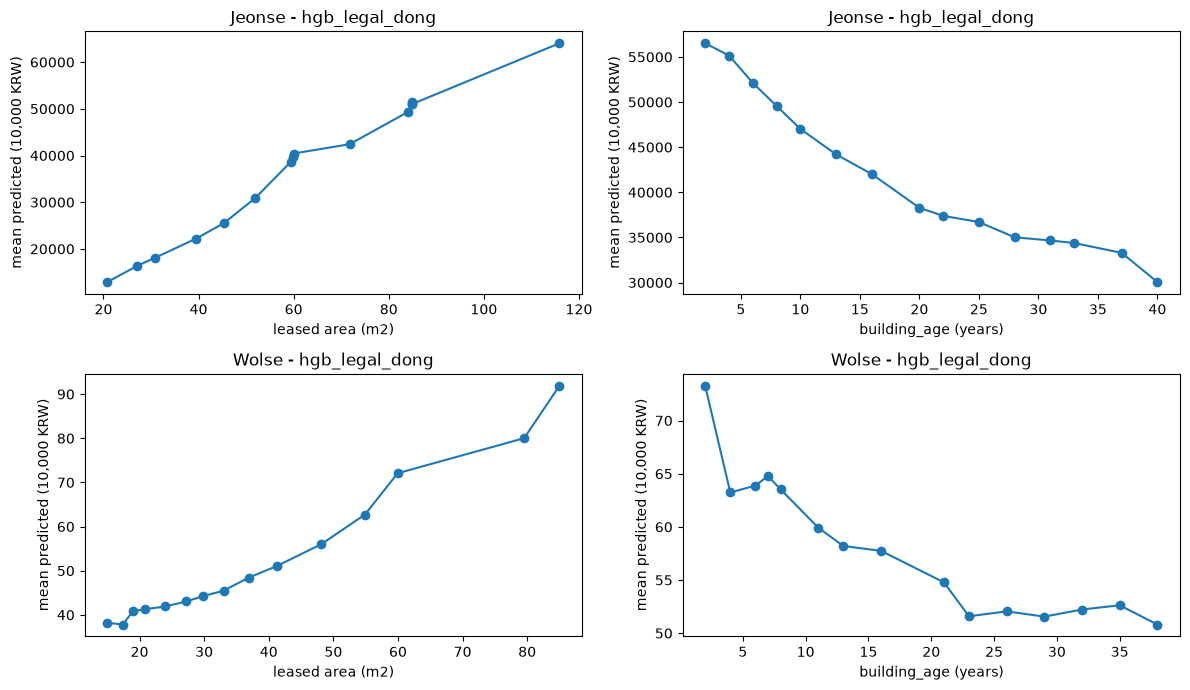

In [9]:
def partial_dependence(model, X, column, variant, n_grid=15):
    cols_ = required_columns(variant)
    grid = np.unique(np.quantile(X[column], np.linspace(0.05, 0.95, n_grid)))
    values = []
    for g in grid:
        Xg = X[cols_].copy(); Xg[column] = g
        values.append(to_original(model.predict(Xg)).mean())
    return grid, np.array(values)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for r, track in enumerate(config.TRACKS):
    d = data[track]; variant = MODELS[best_id[track]]
    X_pd = d['X_test'].sample(3_000, random_state=config.RANDOM_SEED)
    for c, column in enumerate(['log_area', 'building_age']):
        grid, values = partial_dependence(fitted[(track, best_id[track])], X_pd, column, variant)
        x = np.exp(grid) if column == 'log_area' else grid
        axes[r, c].plot(x, values, marker='o')
        axes[r, c].set_xlabel('leased area (m2)' if column == 'log_area' else 'building_age (years)')
        axes[r, c].set_ylabel('mean predicted (10,000 KRW)')
        axes[r, c].set_title(f'{track.capitalize()} - {best_id[track]}')
        print(f"{track} {column}: grid {np.round(x[[0, -1]], 2).tolist()} -> mean prediction {np.round(values[[0, -1]], 2).tolist()}")
plt.tight_layout(); plt.show()

**Interpretation.** The partial dependence has the same shape as in the random forest. In Jeonse the mean prediction goes from 12,901.16 at 20.79 m2 to 64,039.29 at 115.9 m2 and from 56,514.70 at 2 years to 30,054.42 at 40 years. In Wolse it goes from 38.22 at 15.0 m2 to 91.89 at 84.99 m2 and from 73.27 at 2 years to 50.81 at 38 years. As before, these are associations averaged over the observed mix of the other features.

## Residual diagnostics (log scale, TEST, best model)

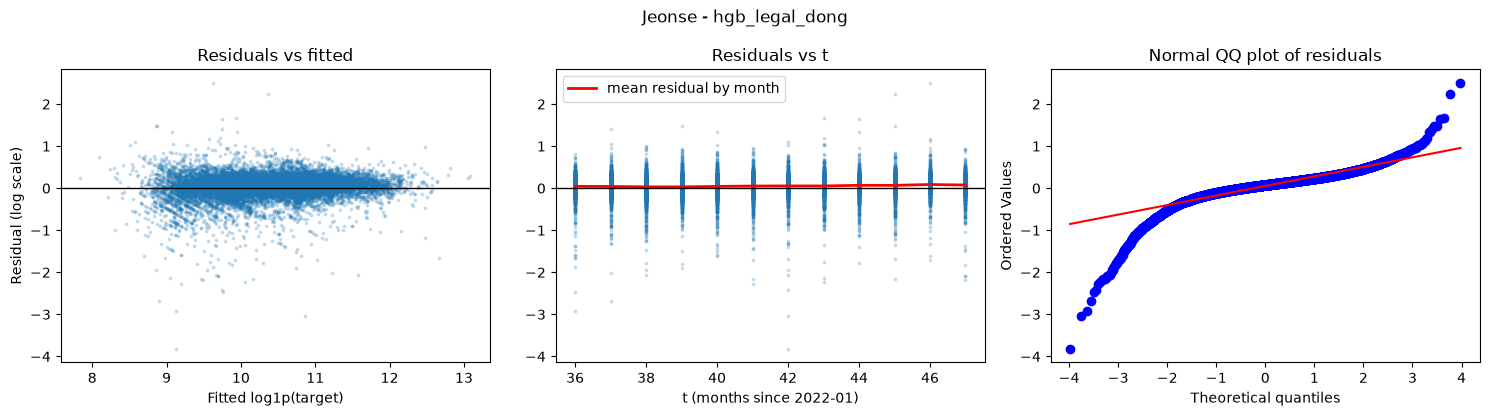

jeonse: residual mean 0.0521, median 0.0765, std 0.2502
jeonse: mean residual by month of 2025 (t = 36..47): {36: 0.0439, 37: 0.0407, 38: 0.0315, 39: 0.0311, 40: 0.0424, 41: 0.0508, 42: 0.0536, 43: 0.0526, 44: 0.0681, 45: 0.0674, 46: 0.0873, 47: 0.0754}


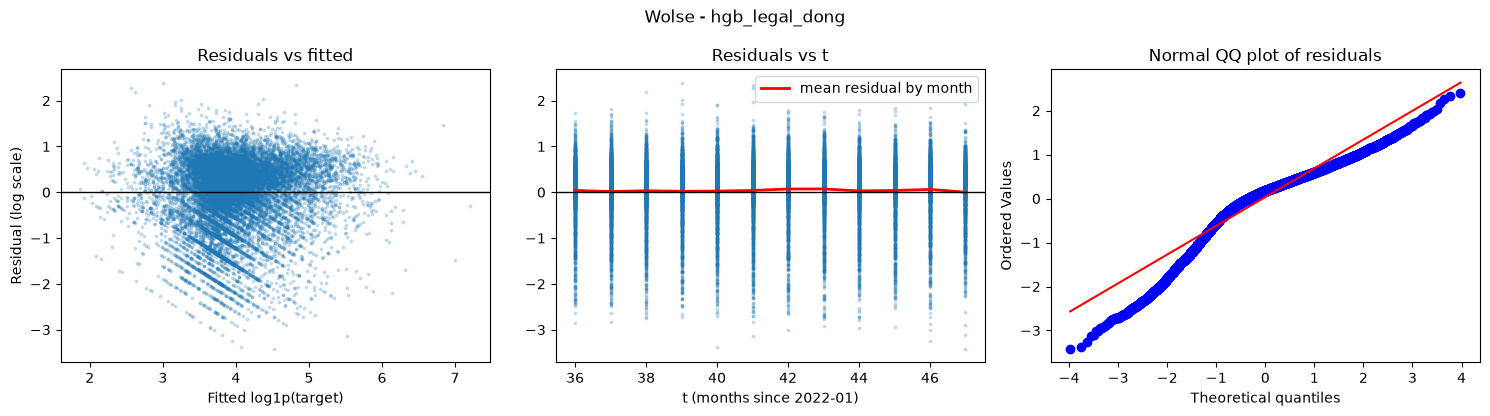

wolse: residual mean 0.0375, median 0.1815, std 0.6827
wolse: mean residual by month of 2025 (t = 36..47): {36: 0.0392, 37: 0.0155, 38: 0.0326, 39: 0.0209, 40: 0.0253, 41: 0.0391, 42: 0.0709, 43: 0.072, 44: 0.0293, 45: 0.0383, 46: 0.0621, 47: 0.0014}


In [10]:
rng = np.random.default_rng(config.RANDOM_SEED)
for track in config.TRACKS:
    d = data[track]
    pred = preds[(track, best_id[track])]
    fitted_log = np.log1p(pred)
    resid = np.log1p(d['y_test'].to_numpy()) - fitted_log
    t_idx = month_index(d['test']['contract_date'])
    sample = rng.choice(len(resid), size=min(20_000, len(resid)), replace=False)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    axes[0].scatter(fitted_log[sample], resid[sample], s=3, alpha=0.2)
    axes[0].axhline(0, color='black', lw=1)
    axes[0].set(xlabel='Fitted log1p(target)', ylabel='Residual (log scale)', title='Residuals vs fitted')
    axes[1].scatter(t_idx[sample], resid[sample], s=3, alpha=0.2)
    mean_by_t = pd.Series(resid).groupby(t_idx).mean()
    axes[1].plot(mean_by_t.index, mean_by_t.values, color='red', lw=2, label='mean residual by month')
    axes[1].axhline(0, color='black', lw=1)
    axes[1].set(xlabel='t (months since 2022-01)', title='Residuals vs t'); axes[1].legend()
    stats.probplot(resid[sample], dist='norm', plot=axes[2])
    axes[2].set_title('Normal QQ plot of residuals')
    fig.suptitle(f'{track.capitalize()} - {best_id[track]}')
    plt.tight_layout(); plt.show()
    print(f"{track}: residual mean {resid.mean():.4f}, median {np.median(resid):.4f}, std {resid.std():.4f}")
    print(f"{track}: mean residual by month of 2025 (t = 36..47):", mean_by_t.round(4).to_dict())

**Interpretation.** Residuals (log1p(actual) minus log1p(prediction)) are positive on average in both tracks: in Jeonse the mean is 0.0521, the median 0.0765 and the standard deviation 0.2502; in Wolse 0.0375, 0.1815 and 0.6827. In Jeonse the mean residual by month rises from 0.0439 (t = 36) to 0.0754 (t = 47), with a maximum of 0.0873 at t = 46, so the underprediction grows during 2025. In Wolse the monthly means stay between 0.0014 and 0.072 without a clear upward path, and the dispersion (0.6827) is larger than in Jeonse (0.2502).

## Error by building_type and district (best model)

In [11]:
for track in config.TRACKS:
    d = data[track]; target = config.TRACKS[track]['target']
    frame = d['test'].assign(pred=preds[(track, best_id[track])])
    by_type = frame.groupby('building_type').apply(
        lambda g: pd.Series({'n_test': len(g), 'wape_pct': wape(g[target], g['pred']),
                             'median_bias_pct': float(np.median((g['pred'] - g[target]) / g[target]) * 100)}),
        include_groups=False).astype({'n_test': int})
    by_district = frame.groupby('district_name').apply(
        lambda g: pd.Series({'n_test': len(g), 'wape_pct': wape(g[target], g['pred'])}),
        include_groups=False).sort_values('wape_pct').astype({'n_test': int})
    print(f'{track} - {best_id[track]}: by building_type'); display(by_type)
    print('Lowest WAPE (five best districts)'); display(by_district.head(5))
    print('Highest WAPE (five worst districts)'); display(by_district.tail(5).iloc[::-1])

jeonse - hgb_legal_dong: by building_type


,n_test,wape_pct,median_bias_pct
building_type,,,
Apartment,22645,15.4896,-8.3140
Detached / Multi-household house,3977,28.7045,-2.3374
Officetel,3369,12.2588,-7.5666
Row house / Villa (multi-unit),7944,15.9751,-5.4271


Lowest WAPE (five best districts)


,n_test,wape_pct
district_name,,
Jung-gu,598,13.0368
Dongdaemun-gu,1463,13.1439
Yeongdeungpo-gu,1997,13.2677
Seongbuk-gu,1347,13.3998
Nowon-gu,1908,13.4497


Highest WAPE (five worst districts)


...

,n_test,wape_pct,median_bias_pct
building_type,,,
Apartment,17911,47.9051,-19.7939
Detached / Multi-household house,17711,30.3799,-10.0668
Officetel,10300,45.3786,-24.7453
Row house / Villa (multi-unit),11907,52.0193,-20.4607


Lowest WAPE (five best districts)


,n_test,wape_pct
district_name,,
Dobong-gu,977,34.5416
Gangbuk-gu,1157,34.8340
Nowon-gu,1885,36.6154
Gwanak-gu,3924,36.9524
Jongno-gu,1008,38.5209


Highest WAPE (five worst districts)


,n_test,wape_pct
district_name,,
Seocho-gu,2686,51.5506
Songpa-gu,4660,50.7708
Gangseo-gu,3873,49.9384
Yongsan-gu,1233,48.8046
Gangnam-gu,3643,47.2219


**Interpretation (Jeonse).** By building type, Officetel has the lowest WAPE (12.26%) and Detached / Multi-household house the highest (28.70%); Apartment has 15.49% and a median bias of -8.31%. By district, WAPE ranges from 13.04% (Jung-gu) to 18.10% (Yangcheon-gu).

**Interpretation (Wolse).** Detached / Multi-household house has the lowest WAPE (30.38%) and Row house / Villa the highest (52.02%); the median bias is negative in every type, from -10.07% (Detached / Multi-household house) to -24.75% (Officetel). By district, WAPE ranges from 34.54% (Dobong-gu) to 51.55% (Seocho-gu).

## Summary

In [12]:
summary = metrics.pivot(index='model_id', columns='track', values=['wape_pct', 'median_bias_pct', 'aggregate_bias_pct']).loc[list(MODELS)]
display(summary)

wape_pct         median_bias_pct          aggregate_bias_pct         
track            jeonse   wolse          jeonse    wolse             jeonse    wolse
model_id                                                                            
hgb_static      18.5858 45.5432         -7.7759 -17.6542            -9.3616 -23.2012
hgb_time        17.3111 45.7417         -3.9480 -18.2042            -4.0113 -22.4644
hgb_detrended   17.6481 45.3293          5.2326 -16.9244             3.3864 -22.4758
hgb_legal_dong  15.8354 44.3335         -7.3684 -16.9086            -8.5658 -21.6673

## Conclusion

- **Best model.** `hgb_legal_dong` has the lowest TEST WAPE in both tracks (15.84% in Jeonse and 44.33% in Wolse), ahead of the random forest (17.91% and 45.76%), the best linear model (23.09% and 49.10%) and the naive baseline (27.25% and 46.96%). Neighbourhood detail is the largest gain over `hgb_static` (18.59% and 45.54%).
- **Level bias.** Boosting does not remove it. The static and legal-dong models underpredict more as 2025 advances in Jeonse (median bias of `hgb_static` from -6.13% in Q1 to -10.77% in Q4), the detrended variant overshoots (+5.23%), and in Wolse every variant has a median bias between -16.91% and -18.20%. Notebook 10 shows that in Wolse a negative aggregate bias also appears in the 2023 and 2024 pseudo-tests and that a large part of it comes from the squared loss on `log1p` (a median-loss objective and a smearing factor reduce it), so it is not a 2025-specific level shift; in Jeonse the sign of the bias depends on the year and on the model.
- **Uncertainty.** The 80% interval covers 0.6889 (Jeonse) and 0.6493 (Wolse) of the 2025 contracts (empirical coverage, as printed), so a model trained on 2022-2024 gives intervals that are too narrow for 2025.